<a href="https://colab.research.google.com/github/duongngusmart/NhapMonPhanTichDuLieuHocSau/blob/main/Tuan2/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Thiết lập font và kích thước mặc định cho biểu đồ dễ nhìn hơn
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Đọc dữ liệu từ Lab 1 (đảm bảo file này đã có trên Colab)
df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')

In [6]:
##YÊU CẦU 1: Thống kê dữ liệu
# 1. Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần
df_sorted_dh1 = df.sort_values(by='DH1')
print("--- Top 5 dòng sau khi sắp xếp DH1 tăng dần ---")
print(df_sorted_dh1[['KT', 'DH1']].head())

# 2. Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính
df_sorted_dh2_gt = df.sort_values(by=['GT', 'DH2'])
print("\n--- Top 5 dòng sau khi sắp xếp DH2 theo GT ---")
print(df_sorted_dh2_gt[['GT', 'DH2']].head())

# Hàm tính Q1, Q2 (Median), Q3 để đưa vào Pivot Table
def q1(x): return x.quantile(0.25)
def q2(x): return x.median()
def q3(x): return x.quantile(0.75)
# Đổi tên hàm để hiển thị đẹp trên bảng
q1.__name__ = 'Q1'
q2.__name__ = 'Q2'
q3.__name__ = 'Q3'

agg_funcs = ['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3]

# 3. Pivot-table DH1 theo KT
print("\n--- Pivot Table DH1 theo KT ---")
pt_kt = pd.pivot_table(df, values='DH1', index='KT', aggfunc=agg_funcs)
print(pt_kt)

# 4. Pivot-table DH1 theo KT và KV
print("\n--- Pivot Table DH1 theo KT và KV ---")
pt_kt_kv = pd.pivot_table(df, values='DH1', index=['KT', 'KV'], aggfunc=agg_funcs)
print(pt_kt_kv)

# 5. Pivot-table DH1 theo KT, KV và DT
print("\n--- Pivot Table DH1 theo KT, KV, DT ---")
pt_kt_kv_dt = pd.pivot_table(df, values='DH1', index=['KT', 'KV', 'DT'], aggfunc=agg_funcs)
print(pt_kt_kv_dt)

--- Top 5 dòng sau khi sắp xếp DH1 tăng dần ---
    KT  DH1
12  D1  3.1
88  D1  3.2
43   A  3.3
38  A1  3.3
91   C  3.4

--- Top 5 dòng sau khi sắp xếp DH2 theo GT ---
   GT  DH2
78  F  3.0
79  F  3.3
51  F  3.4
94  F  3.5
2   F  3.9

--- Pivot Table DH1 theo KT ---
   count    sum      mean median  min  max       std     Q1    Q2     Q3
     DH1    DH1       DH1    DH1  DH1  DH1       DH1    DH1   DH1    DH1
KT                                                                      
A     18  122.3  6.794444   7.30  3.3  9.9  2.343821  4.925  7.30  9.075
A1    23  144.6  6.286957   5.90  3.3  9.4  2.129726  4.050  5.90  8.500
B     14   92.1  6.578571   6.25  3.6  9.5  2.102079  4.675  6.25  8.375
C     28  168.4  6.014286   5.30  3.4  9.7  2.165677  4.300  5.30  7.800
D1    17   96.7  5.688235   5.20  3.1  9.0  1.788813  4.700  5.20  7.300

--- Pivot Table DH1 theo KT và KV ---
       count   sum      mean median  min  max       std     Q1    Q2     Q3
         DH1   DH1       DH1    DH

Bảng tần số Giới tính:
 GT
F    56
M    44
Name: count, dtype: int64

Bảng tần suất Giới tính (%):
 GT
F    56.0
M    44.0
Name: proportion, dtype: float64


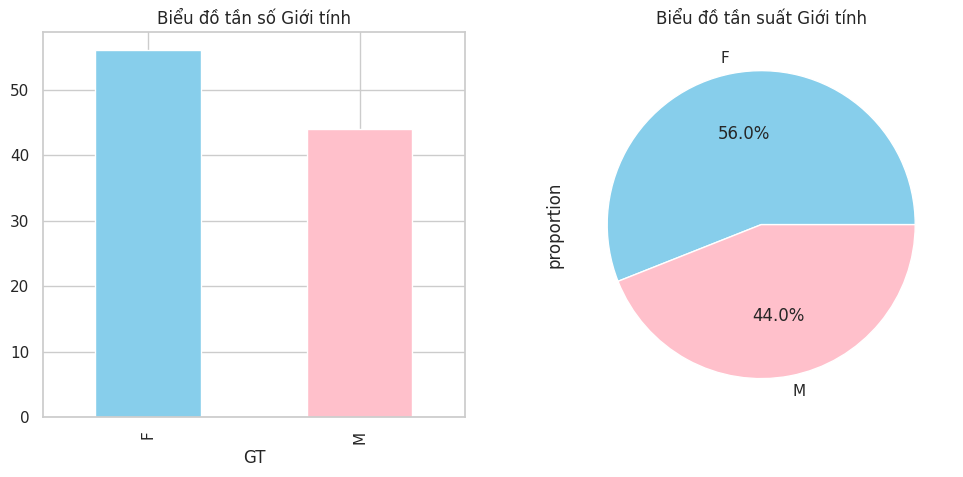


--- Thống kê mô tả US_TBM1, US_TBM2, US_TBM3 ---
          US_TBM1     US_TBM2     US_TBM3
count  100.000000  100.000000  100.000000
mean     2.554643    2.606090    2.589094
std      0.300415    0.318514    0.305640
min      1.932000    1.912000    1.881567
25%      2.346000    2.365979    2.395000
50%      2.530000    2.624000    2.602000
75%      2.730000    2.859000    2.750000
max      3.336000    3.316000    3.388000

--- Tần số Dân tộc của học sinh Nam ---
DT
Kinh     31
0         6
Hoa       3
Khmer     2
Chăm      2
Name: count, dtype: int64

--- Tần số Khu vực thỏa mãn điều kiện ---
KV
2      8
3      5
2NT    3
1      1
Name: count, dtype: int64

--- Dữ liệu điểm DH thỏa mãn ĐK khu vực 2NT ---
    DH1  DH2  DH3
4   8.7  9.5  9.1
9   9.0  6.8  6.0
11  9.0  6.9  7.9
18  9.2  8.3  6.9
23  5.8  9.2  8.0
30  8.6  6.0  5.1
31  8.2  5.4  6.7
63  5.3  8.2  5.3
75  7.5  6.1  6.6


In [7]:
##PHẦN 2: Trình bày dữ liệu
# 1. Trình bày dữ liệu biến GT
tan_so_gt = df['GT'].value_counts()
tan_suat_gt = df['GT'].value_counts(normalize=True) * 100

print("Bảng tần số Giới tính:\n", tan_so_gt)
print("\nBảng tần suất Giới tính (%):\n", tan_suat_gt)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
tan_so_gt.plot(kind='bar', ax=ax[0], title='Biểu đồ tần số Giới tính', color=['skyblue', 'pink'])
tan_suat_gt.plot(kind='pie', ax=ax[1], title='Biểu đồ tần suất Giới tính', autopct='%1.1f%%', colors=['skyblue', 'pink'])
plt.show()

# 2. Trình bày dữ liệu US_TBM1, US_TBM2, US_TBM3
print("\n--- Thống kê mô tả US_TBM1, US_TBM2, US_TBM3 ---")
print(df[['US_TBM1', 'US_TBM2', 'US_TBM3']].describe())

# 3. Trình bày biến DT với học sinh là nam ('M')
print("\n--- Tần số Dân tộc của học sinh Nam ---")
print(df[df['GT'] == 'M']['DT'].value_counts())

# 4. KV với học sinh nam, dân tộc Kinh, thỏa điều kiện DH1 >= 5, DH2 >= 4, DH3 >= 4
cond = (df['GT'] == 'M') & (df['DT'] == 'Kinh') & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)
print("\n--- Tần số Khu vực thỏa mãn điều kiện ---")
print(df[cond]['KV'].value_counts())

# 5. DH1, DH2, DH3 >= 5 và thuộc khu vực 2NT
cond2 = (df['KV'] == '2NT') & (df['DH1'] >= 5.0) & (df['DH2'] >= 5.0) & (df['DH3'] >= 5.0)
print("\n--- Dữ liệu điểm DH thỏa mãn ĐK khu vực 2NT ---")
print(df[cond2][['DH1', 'DH2', 'DH3']])

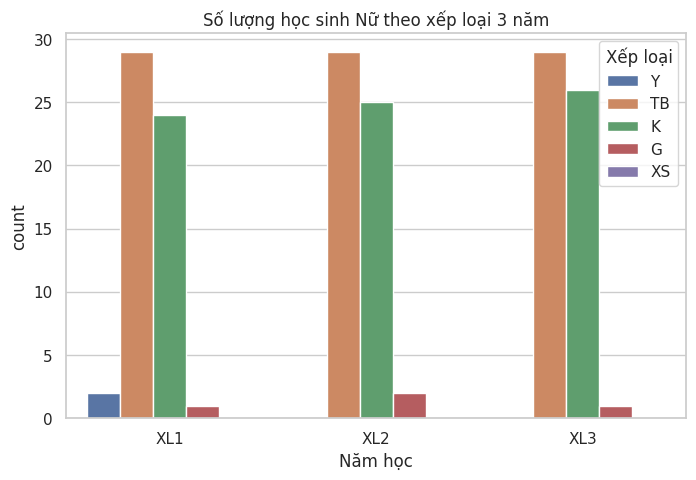

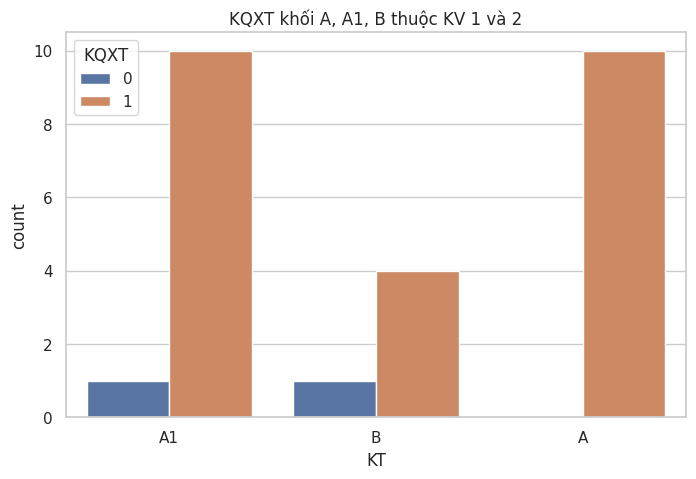

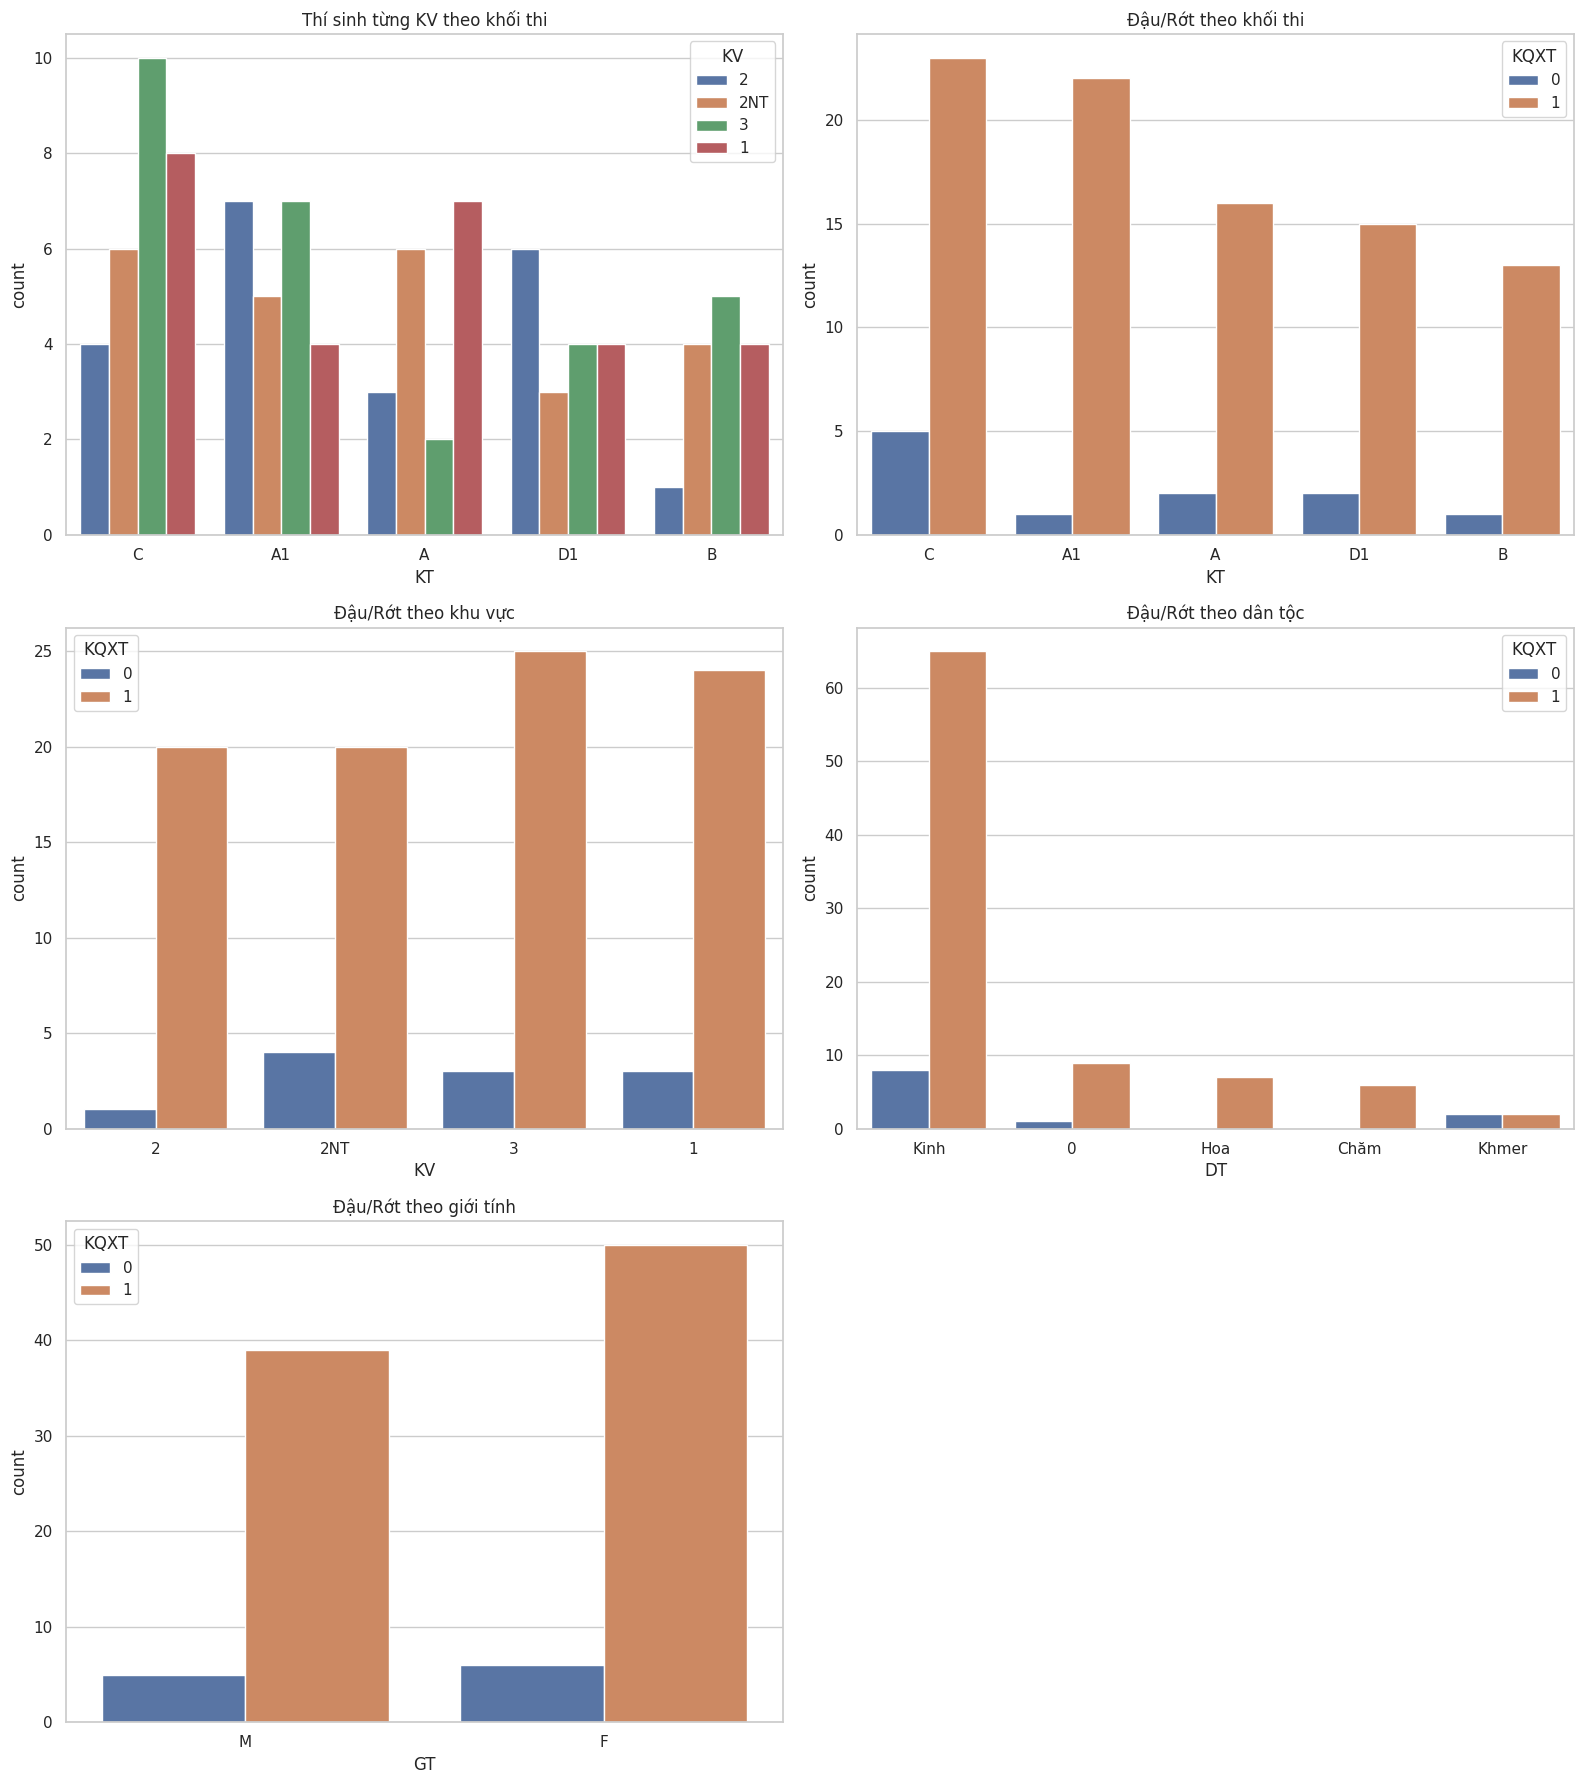

In [8]:
##PHẦN 3: Trực quan hóa dữ liệu theo nhóm phân loại
# 1. Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
df_nu = df[df['GT'] == 'F'][['XL1', 'XL2', 'XL3']]
df_nu_melt = df_nu.melt(var_name='Năm học', value_name='Xếp loại')

plt.figure(figsize=(8, 5))
sns.countplot(data=df_nu_melt, x='Năm học', hue='Xếp loại', hue_order=['Y', 'TB', 'K', 'G', 'XS'])
plt.title('Số lượng học sinh Nữ theo xếp loại 3 năm')
plt.show()

# 2. KQXT trên nhóm khối A, A1, B thuộc khu vực 1, 2
df_k_kv = df[(df['KT'].isin(['A', 'A1', 'B'])) & (df['KV'].isin(['1', '2']))]
plt.figure(figsize=(8, 5))
sns.countplot(data=df_k_kv, x='KT', hue='KQXT')
plt.title('KQXT khối A, A1, B thuộc KV 1 và 2')
plt.show()

# Biểu đồ lưới cho các câu 3, 4, 5, 6, 7
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 3. Số lượng thí sinh từng khu vực theo khối thi
sns.countplot(data=df, x='KT', hue='KV', ax=axes[0, 0]).set_title('Thí sinh từng KV theo khối thi')

# 4. Thí sinh đậu/rớt theo khối thi
sns.countplot(data=df, x='KT', hue='KQXT', ax=axes[0, 1]).set_title('Đậu/Rớt theo khối thi')

# 5. Thí sinh đậu/rớt theo khu vực
sns.countplot(data=df, x='KV', hue='KQXT', ax=axes[1, 0]).set_title('Đậu/Rớt theo khu vực')

# 6. Thí sinh đậu/rớt theo dân tộc
sns.countplot(data=df, x='DT', hue='KQXT', ax=axes[1, 1]).set_title('Đậu/Rớt theo dân tộc')

# 7. Thí sinh đậu/rớt theo giới tính
sns.countplot(data=df, x='GT', hue='KQXT', ax=axes[2, 0]).set_title('Đậu/Rớt theo giới tính')

axes[2, 1].axis('off') # Ẩn ô trống
plt.tight_layout()
plt.show()

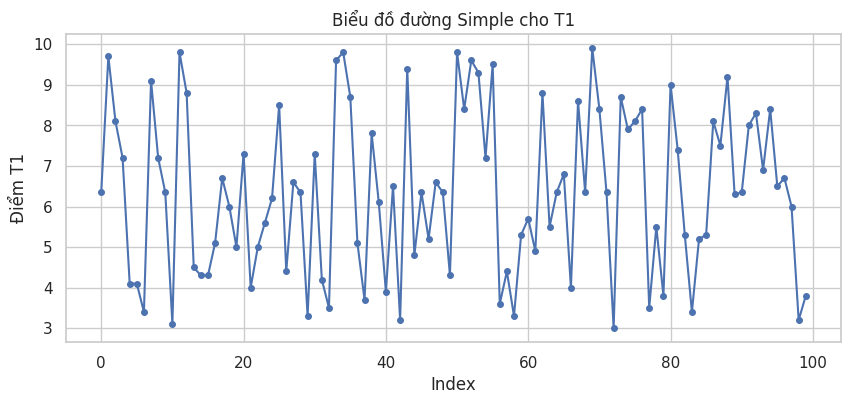


Bảng tần số phân loại T1:
 phanlopt1
tb     35
kem    28
g      28
k       9
Name: count, dtype: int64


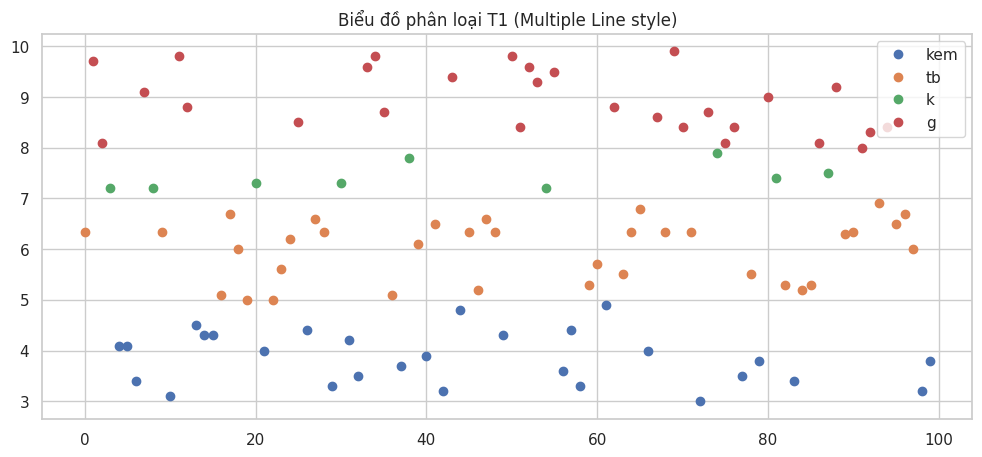

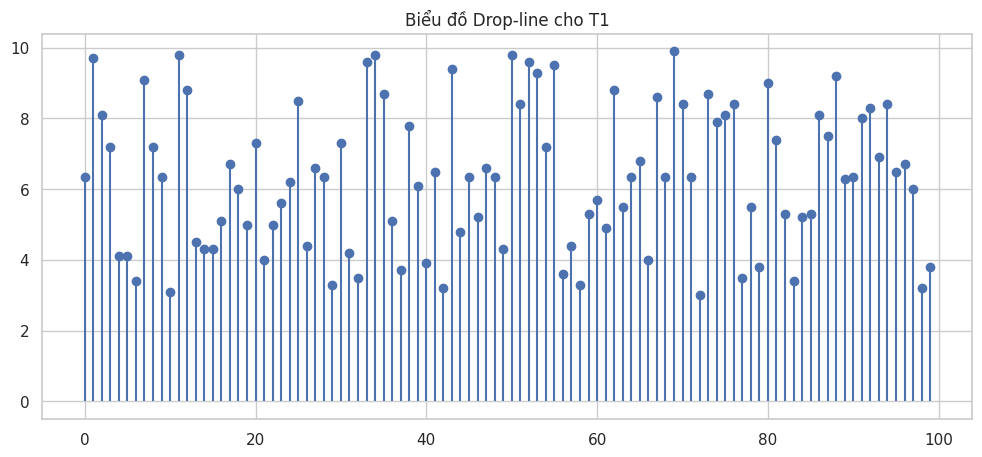

In [9]:
##PHẦN 4: Trực quan hóa dữ liệu nâng cao
# 1. Vẽ biểu đồ đường Simple cho biến T1
plt.figure(figsize=(10, 4))
plt.plot(df['T1'], marker='o', linestyle='-', markersize=4)
plt.title('Biểu đồ đường Simple cho T1')
plt.xlabel('Index')
plt.ylabel('Điểm T1')
plt.show()

# 2. Tạo biến phân loại phanlopt1
bins = [-1, 5, 7, 8, 11] # Giới hạn các khoảng điểm
labels = ['kem', 'tb', 'k', 'g']
df['phanlopt1'] = pd.cut(df['T1'], bins=bins, labels=labels, right=False)

# 3. Lập bảng tần số cho biến phanlopt1
print("\nBảng tần số phân loại T1:\n", df['phanlopt1'].value_counts())

# 4. Multiple Line cho T1 phân loại bởi phanlopt1
plt.figure(figsize=(12, 5))
for loai in labels:
    subset = df[df['phanlopt1'] == loai]
    plt.plot(subset.index, subset['T1'], marker='o', linestyle='', label=loai) # Dùng scatter giả line để nhìn rõ các nhóm rời rạc
plt.title('Biểu đồ phân loại T1 (Multiple Line style)')
plt.legend()
plt.show()

# 5. Biểu đồ Drop-line (Stem) cho T1 phân loại bởi phanlopt1
plt.figure(figsize=(12, 5))
# Lấy màu dựa trên nhãn phân loại
colors = df['phanlopt1'].map({'kem': 'red', 'tb': 'orange', 'k': 'blue', 'g': 'green'})
plt.stem(df.index, df['T1'], basefmt=" ", bottom=0)
plt.title('Biểu đồ Drop-line cho T1')
plt.show()

--- Mô tả đặc trưng phân phối T1 ---
count    100.000000
mean       6.346154
std        2.023264
min        3.000000
25%        4.475000
50%        6.346154
75%        8.100000
max        9.900000
Name: T1, dtype: float64
Độ lệch (Skewness): 0.09124541404859414
Độ nhọn (Kurtosis): -1.1332752779483815


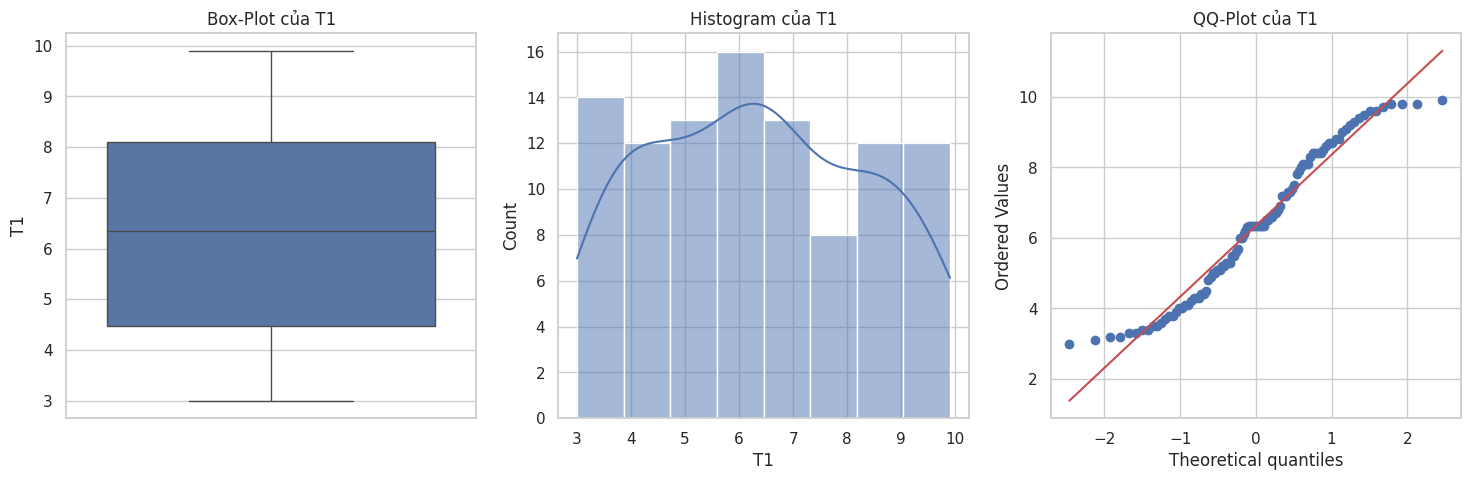

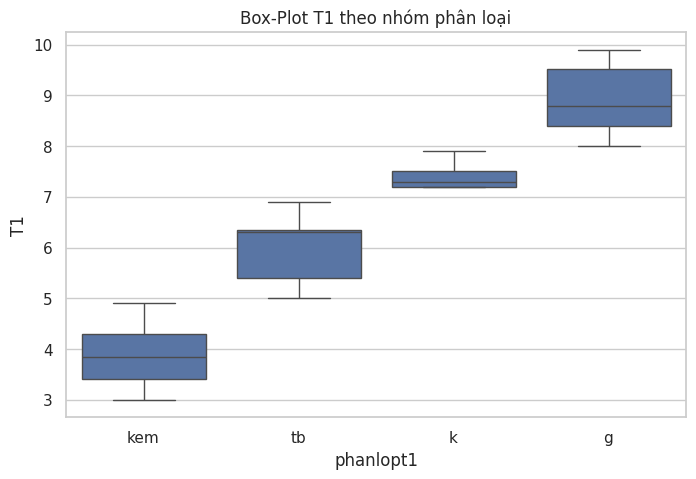


--- Tương quan giữa DH1 và T1 ---
Ma trận Covariance:
           DH1        T1
DH1  4.467090 -0.661927
T1  -0.661927  4.093598

Ma trận Correlation:
           DH1        T1
DH1  1.000000 -0.154791
T1  -0.154791  1.000000


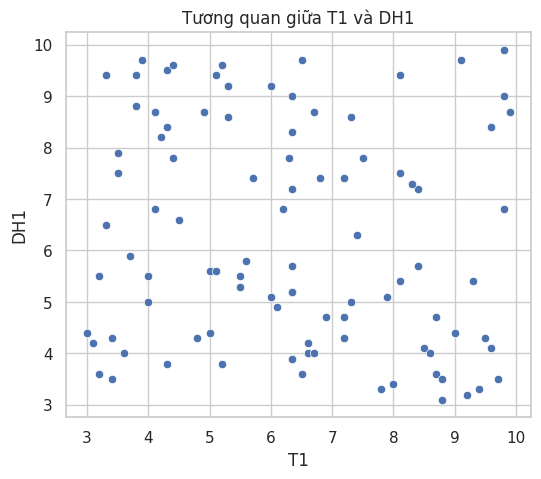

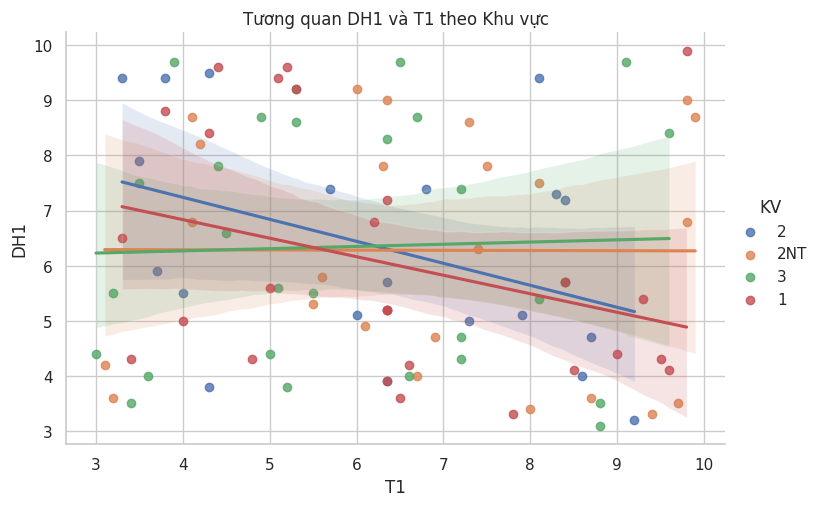


--- Ma trận tương quan DH1, DH2, DH3 ---
          DH1       DH2       DH3
DH1  1.000000 -0.220022 -0.042150
DH2 -0.220022  1.000000 -0.028698
DH3 -0.042150 -0.028698  1.000000


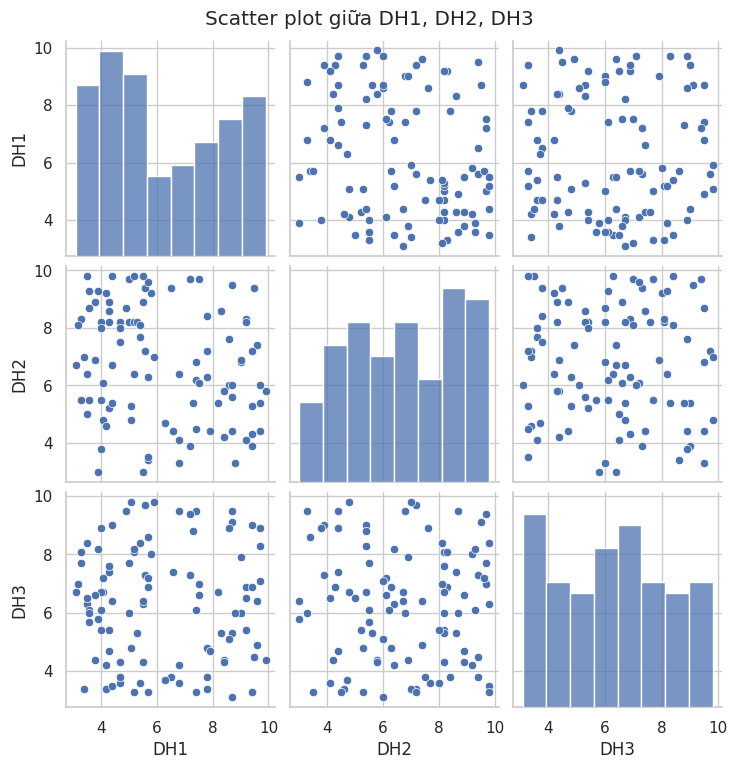

In [10]:
##PHẦN 5: Mô tả dữ liệu và khảo sát dạng phân phối
# 1. Mô tả và khảo sát phân phối biến T1
print("--- Mô tả đặc trưng phân phối T1 ---")
print(df['T1'].describe())
print("Độ lệch (Skewness):", df['T1'].skew())
print("Độ nhọn (Kurtosis):", df['T1'].kurtosis())

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Box-Plot
sns.boxplot(y=df['T1'], ax=ax[0])
ax[0].set_title('Box-Plot của T1')

# Histogram
sns.histplot(df['T1'], kde=True, ax=ax[1])
ax[1].set_title('Histogram của T1')

# QQ-Plot
stats.probplot(df['T1'], dist="norm", plot=ax[2])
ax[2].set_title('QQ-Plot của T1')
plt.show()

# 2. Khảo sát phân phối T1 theo từng nhóm phanlopT1 (Box-Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='phanlopt1', y='T1')
plt.title('Box-Plot T1 theo nhóm phân loại')
plt.show()

# 3. Khảo sát tương quan giữa DH1 và T1
print("\n--- Tương quan giữa DH1 và T1 ---")
print("Ma trận Covariance:\n", df[['DH1', 'T1']].cov())
print("\nMa trận Correlation:\n", df[['DH1', 'T1']].corr())

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='T1', y='DH1')
plt.title('Tương quan giữa T1 và DH1')
plt.show()

# 4. Tương quan DH1 theo T1 trên từng nhóm khu vực
sns.lmplot(data=df, x='T1', y='DH1', hue='KV', height=5, aspect=1.5)
plt.title('Tương quan DH1 và T1 theo Khu vực')
plt.show()

# 5. Khảo sát tương quan giữa DH1, DH2, DH3
print("\n--- Ma trận tương quan DH1, DH2, DH3 ---")
print(df[['DH1', 'DH2', 'DH3']].corr())

sns.pairplot(df[['DH1', 'DH2', 'DH3']])
plt.suptitle('Scatter plot giữa DH1, DH2, DH3', y=1.02)
plt.show()